# Task: Edge Detection Filters 

**Goal:** apply every filter we covered to **your own picture**, compare the results, and explain what you see.

**Rules**
- Use your own image (a photo with clear objects and some texture works best, not a blank wall).
- Write the code yourself where you see `# TODO`. Hints are given, not solutions.
- Every plot needs a title. Use `plt.figure(figsize=...)` so images are readable.

**Submit:** this notebook with outputs visible + your answers.

## Part 0: Setup & Load Your Image

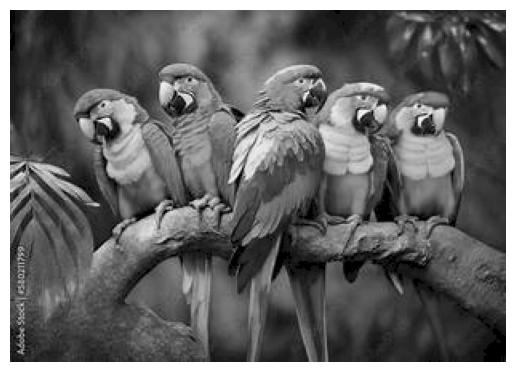

(220, 310)


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

path = r"parrot.png"

#Load the image in grayscale
img= cv2.imread(path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()
print(img.shape)

**Question 0:** What is the size (height × width) of your image? Why do we convert to grayscale before edge detection?

The size of my image is 220 height, 310 width pixels (height × width).

We convert the image to grayscale before edge detection because edge detection mainly depends on changes in brightness or intensity rather than color. Grayscale also reduces the image from three color channels (BGR) to one intensity channel, making the edge detection process simpler and faster.

## Part 1: Gradients (Sobel)

Compute the horizontal and vertical derivatives, then the magnitude and orientation.

Formulas: `mag = sqrt(gx² + gy²)` and `θ = arctan2(gy, gx)`

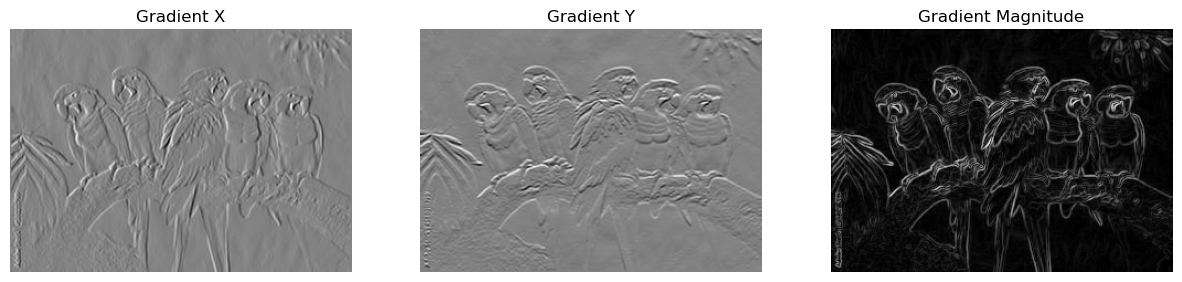

In [ ]:
grad_x= cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3) #detects intensity changes horizontally (vertical edges)
grad_y= cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3) #detects intensity changes vertically (horizontal edges)

magnitude= cv2.magnitude(grad_x.astype(np.float32), grad_y.astype(np.float32)) #shows the strength of the edge
orientation= cv2.phase(grad_x.astype(np.float32),grad_y.astype(np.float32),angleInDegrees=True) #hows the strength of the edge

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(grad_x, cmap="gray")
plt.title("Gradient X")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(grad_y, cmap="gray")
plt.title("Gradient Y")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(magnitude, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")

plt.show()

**Question 1a:** Which gradient (X or Y) highlights vertical lines in your image? Point out one object in your picture that proves it.

**Question 1b:** Why do we use `cv2.CV_64F` instead of the default `uint8` here? (Hint: what happens to negative values?)

1,a- The X gradient grad X highlights vertical lines in the image because it detects changes in intensity from left to right. In my image, the vertical edges of the parrot's body are examples of features that become visible in the X gradient.

1,b- We use cv2.CV_64F because the Sobel operation can produce negative gradient values. If we used the default uint8, negative values could be clipped or wrapped around, causing information to be lost. CV_64F allows both positive and negative values to be stored correctly, giving us an accurate representation of the gradients.

## Part 2: Laplacian

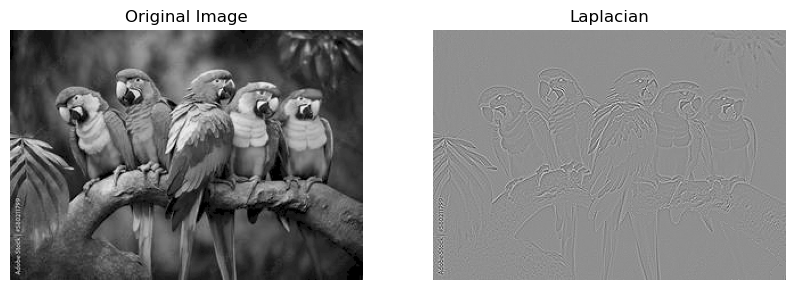

In [4]:
laplacian= cv2.Laplacian(img, cv2.CV_64F)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(laplacian, cmap="gray")
plt.title("Laplacian")
plt.axis("off")

plt.show()

**Question 2:** What is the difference between what the Laplacian gives you and what the Sobel gradients gave you? Does it tell you the edge direction?

*Your answer:* 
The Sobel gradients give information about the intensity changes in the X and Y directions separately, so they can show both the strength and direction of an edge. The Laplacian combines changes in both directions and mainly highlights areas where the intensity changes rapidly, such as edges and fine details.
Laplacian does not directly give us the edge direction 


## Part 3: Canny

Try **three different threshold pairs** (low, high), for example a low pair, a medium pair, and a high pair.

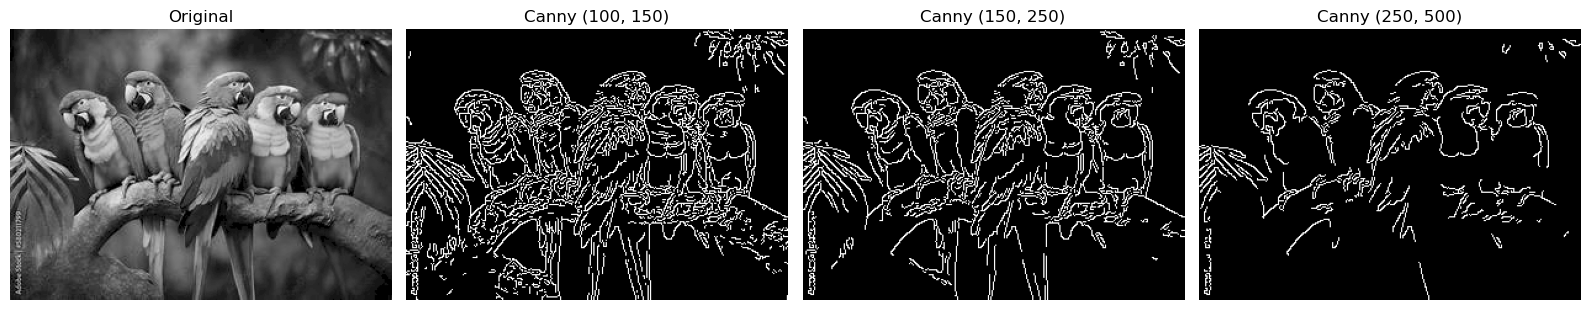

In [5]:
edges1= cv2.Canny(img, 100, 150)
edges2= cv2.Canny(img, 150, 250)
edges3= cv2.Canny(img, 250, 500)


plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(edges1, cmap="gray")
plt.title("Canny (100, 150)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(edges2, cmap="gray")
plt.title("Canny (150, 250)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(edges3, cmap="gray")
plt.title("Canny (250, 500)")
plt.axis("off")

plt.tight_layout()
plt.show()

**Question 3a:** What happens to the edges as you increase the thresholds?

**Question 3b:** List the 5 steps of the Canny pipeline in order.

*Your answers:* 
3-a) As the thresholds increase, fewer edges are detected. Weak edges and small details are gradually removed, leaving mainly the stronger and more significant edges.

3-b) 1-Gaussian smoothing – reduces noise in the image.

2-Gradient calculation – calculates the intensity changes and edge directions.

3-Non-maximum suppression – makes the detected edges thinner.

4-Double thresholding – classifies pixels as strong, weak, or non-edges.

5-Edge tracking by hysteresis – keeps weak edges that are connected to strong edges and removes isolated weak edges.

## Part 4: Roberts & Prewitt (Your Own Kernels)

Define the kernels yourself as NumPy arrays and apply them with `cv2.filter2D`.

- Roberts: 2×2 kernels
- Prewitt: 3×3 kernels (X and Y)

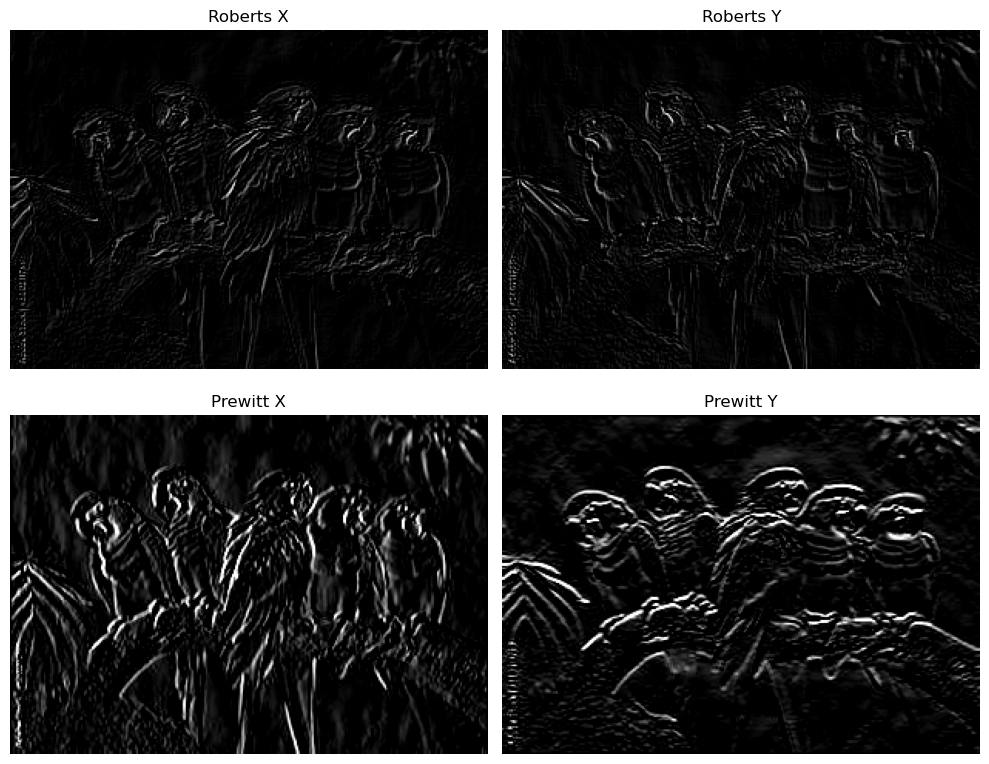

In [6]:
roberts_x= np.array([
    [1, 0],
    [0, -1]
    ], dtype=np.float32) #roberts operator kernel for detecting edges in the x-direction

roberts_y= np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32) #roberts operator kernel for detecting edges in the y-direction


prewitt_x= np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32) #prewitt operator kernel for detecting edges in the x-direction

prewitt_y= np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
], dtype=np.float32) #prewitt operator kernel for detecting edges in the y-direction

#the difference between the roberts and prewitt operators is that the roberts operator uses a 2x2 kernel
#while the prewitt operator uses a 3x3 kernel. 
#The prewitt operator is more sensitive to noise and can detect edges in more directions than the roberts operator.



roberts_x_result= cv2.filter2D(img, -1, roberts_x)
roberts_y_result= cv2.filter2D(img, -1, roberts_y)

prewitt_x_result= cv2.filter2D(img, -1, prewitt_x)
prewitt_y_result= cv2.filter2D(img, -1, prewitt_y)


plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(roberts_x_result, cmap="gray")
plt.title("Roberts X")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(roberts_y_result, cmap="gray")
plt.title("Roberts Y")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(prewitt_x_result, cmap="gray")
plt.title("Prewitt X")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(prewitt_y_result, cmap="gray")
plt.title("Prewitt Y")
plt.axis("off")

plt.tight_layout()
plt.show()

**Question 4:** Which one (Roberts or Prewitt) looks noisier on your image? Why do you think that is (think about kernel size)?

*Your answer:* 
prewitt looks noisier (especially prewitt X) because it uses a larger kernel, which considers more neighboring pixels and detects more intensity changes and edges(sensitive to noise). Robert uses a smaller kernel, producing fewer and thinner edge responses.

## Part 5: Sobel 3×3 vs 5×5

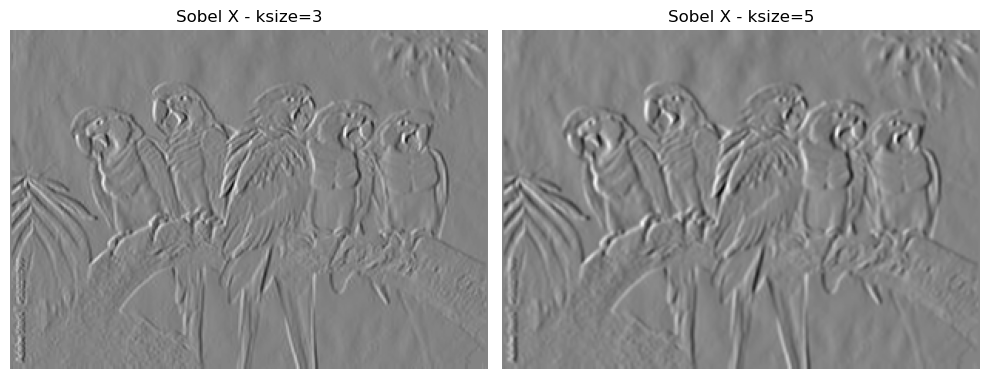

In [ ]:
sobel_x_3= cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3) #ksize=3 means that the Sobel operator will use a 3x3 kernel to compute the gradient in the x-direction.  
sobel_x_5= cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5) #the same applies for ksize=5

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(sobel_x_3, cmap="gray")
plt.title("Sobel X - ksize=3")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sobel_x_5, cmap="gray")
plt.title("Sobel X - ksize=5")
plt.axis("off")

plt.tight_layout()
plt.show()
#Sobel operator with a larger kernel size (ksize=5) produces a smoother result(can be useful for reducing noise)


**Question 5:** Describe the visible difference between the two. When would you choose 5×5 over 3×3?

*Your answer:* 
The 3×3 Sobel filter detects finer details and produces sharper edges, while the 5×5 Sobel filter considers a larger neighborhood of pixels, so the result appears smoother and less sensitive to small details or noise.

I would choose a 5×5 kernel when the image contains more noise or when I want to detect larger and smoother edges. I would choose 3×3 when I want to preserve finer details and smaller features.

## Part 6: Gaussian, LoG & DoG

1. Blur the image with a Gaussian.
2. Apply the Laplacian on the blurred image (**LoG**).
3. Subtract two Gaussian blurs with different sigmas (**DoG**).

Then repeat the DoG with a **second pair of sigmas** (for example `(1, 2)` and `(2, 4)`) and compare.

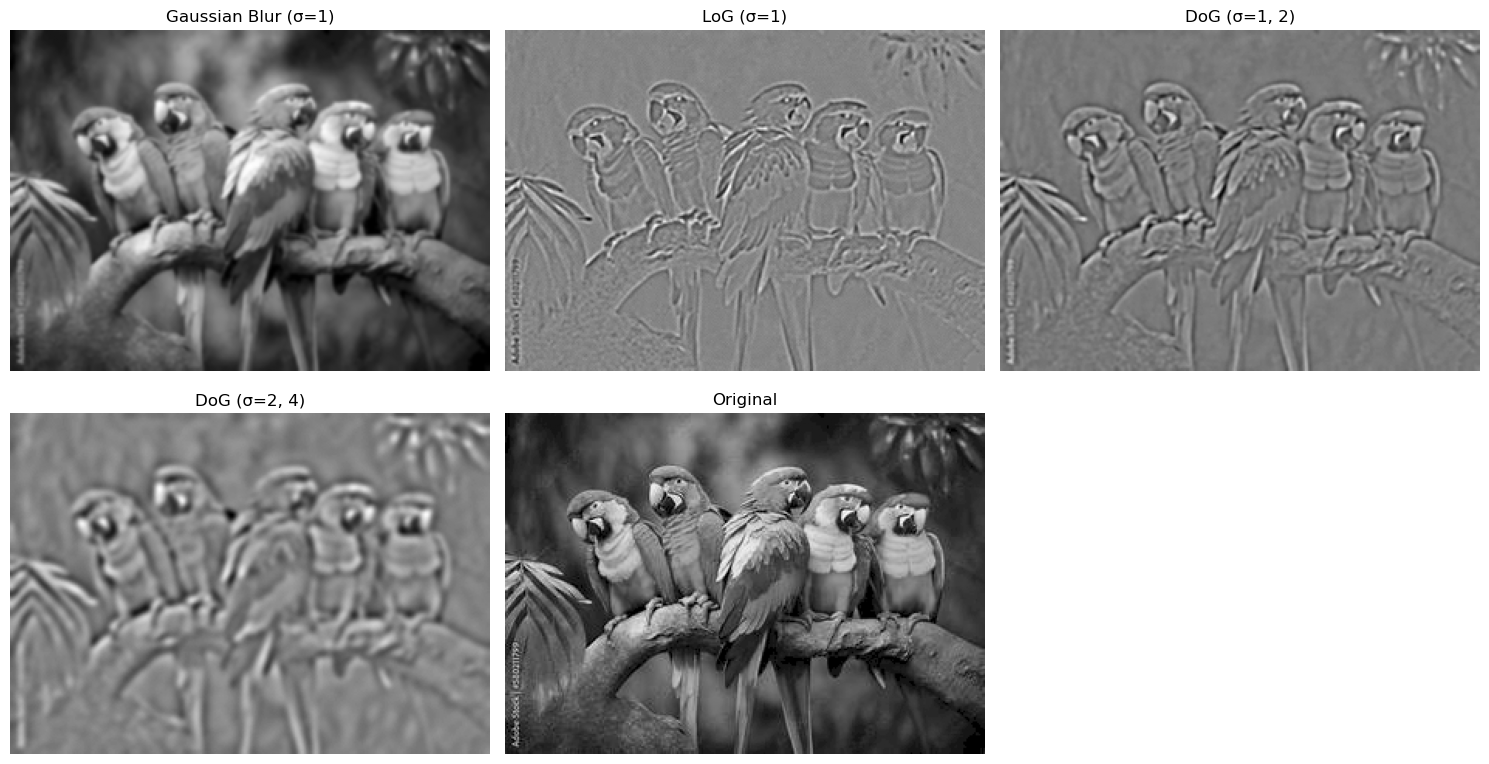

In [8]:
sigma= 1 #a larger sigma results is a more blurred img
blurred= cv2.GaussianBlur(img, (0, 0), sigma)

log= cv2.Laplacian(blurred, cv2.CV_64F) 

gaussian1= cv2.GaussianBlur(img, (0, 0), 1)
gaussian2= cv2.GaussianBlur(img, (0, 0), 2) #sigma= 2 more blurred than sigma=1 
dog1= gaussian1.astype(np.float64) - gaussian2.astype(np.float64)

gaussian3= cv2.GaussianBlur(img, (0, 0), 2)
gaussian4= cv2.GaussianBlur(img, (0, 0), 4) #more blurred than sigma=2 
dog2= gaussian3.astype(np.float64) - gaussian4.astype(np.float64)


plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blur (σ=1)")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(log, cmap="gray")
plt.title("LoG (σ=1)")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(dog1, cmap="gray")
plt.title("DoG (σ=1, 2)")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(dog2, cmap="gray")
plt.title("DoG (σ=2, 4)")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.tight_layout()
plt.show()

**Question 6a:** Why do we blur before applying the Laplacian?

**Question 6b:** What changes in the DoG result when you increase the sigmas?

**Question 6c:** Which algorithm uses DoG for blob detection?

*Your answers:* 
 We blur the image before applying the Laplacian to reduce noise and small unwanted details. The Laplacian is sensitive to rapid intensity changes, so blurring helps prevent noise from being detected as edges.

 When the sigma values increase, the image is smoothed more strongly, so smaller details and fine features are reduced. The DoG result therefore focuses more on larger-scale structures and blobs.

 The SIFT algorithm uses Difference of Gaussians (DoG) for blob/keypoint detection.

## Part 7: Noise Experiment

Add noise to your image and see which filters survive.

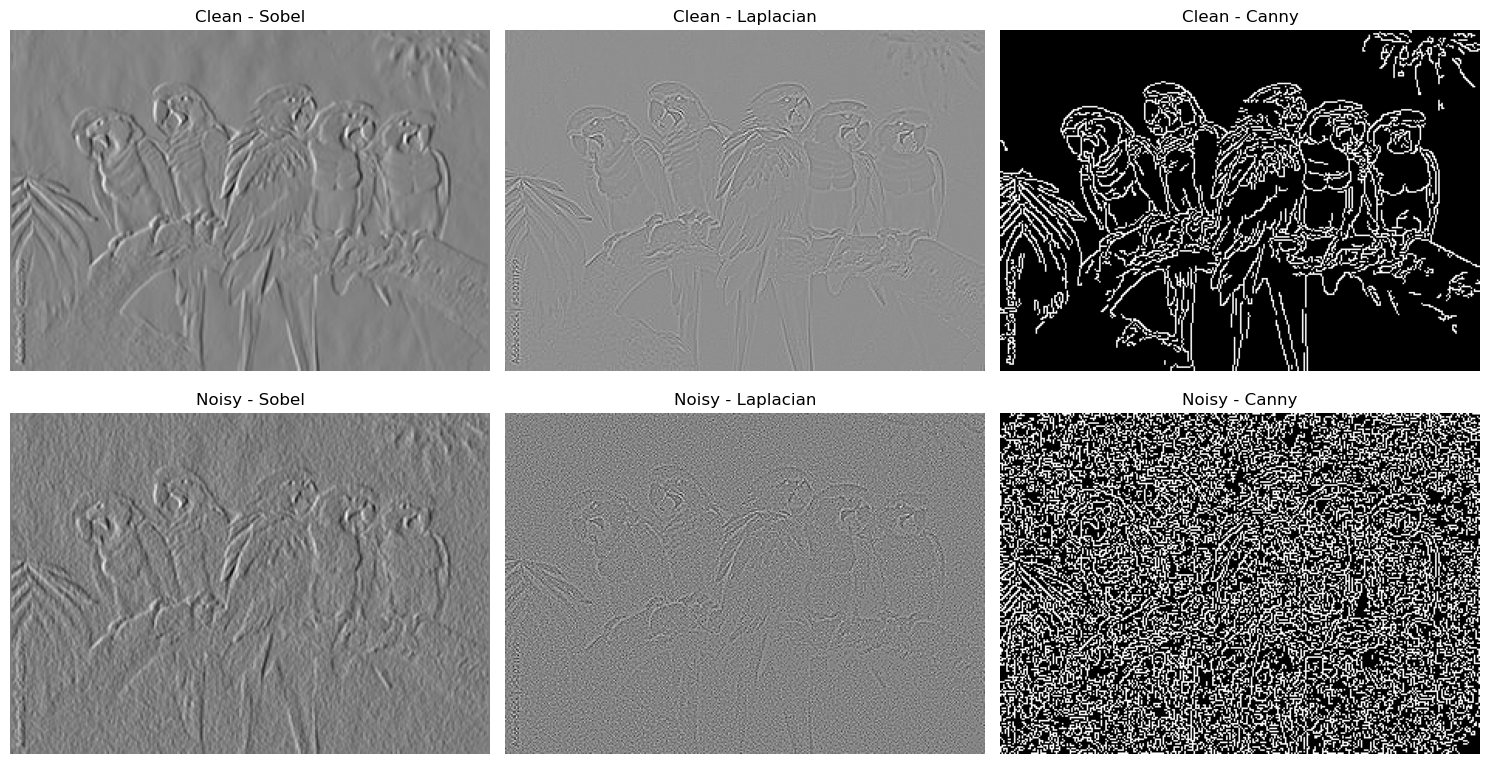

In [10]:
noise= np.random.normal(0, 25, img.shape) #random noise with mean 0 and standard deviation 25
noisy= np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8) #add noise to the original image to be in range [0, 255] and convert to uint8


#Sobel 3x3
sobel= cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)

#Laplacian
laplacian= cv2.Laplacian(img, cv2.CV_64F)

#Canny
canny= cv2.Canny(img, 100, 200)


sobel_noisy = cv2.Sobel(noisy, cv2.CV_64F, 1, 0, ksize=3) #noisy image with Sobel operator applied

laplacian_noisy = cv2.Laplacian(noisy, cv2.CV_64F) #noisy image with Laplacian operator applied

canny_noisy = cv2.Canny(noisy, 100, 200) #noisy image with Canny edge detection applied


plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(sobel, cmap="gray")
plt.title("Clean - Sobel")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(laplacian, cmap="gray")
plt.title("Clean - Laplacian")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(canny, cmap="gray")
plt.title("Clean - Canny")
plt.axis("off")

# Noisy results
plt.subplot(2, 3, 4)
plt.imshow(sobel_noisy, cmap="gray")
plt.title("Noisy - Sobel")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(laplacian_noisy, cmap="gray")
plt.title("Noisy - Laplacian")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(canny_noisy, cmap="gray")
plt.title("Noisy - Canny")
plt.axis("off")

plt.tight_layout()
plt.show()

**Question 7:** Which filter was hurt the most by noise, and which handled it best? Explain why, using what you know about derivatives and smoothing.

*Your answer:* 

Canny, affected the most: The noisy Canny image is almost completely covered with false edges. Canny relies heavily on gradient/derivative information, so random noise creates many sudden intensity changes that are detected as edges. Since noise contains high-frequency variations, the derivative responds strongly to it.


Laplacian, handled it best: The noisy Laplacian image still looks relatively similar to the clean one, with the main bird edges remaining visible. However, the Laplacian is also a second derivative, so theoretically it can be very sensitive to noise too. In your experiment, its response appears less visually dominated by the noise, likely because of how the filter/kernel and image scaling were implemented.


Sobel, in between: Sobel uses the first derivative to detect edges, so noise also affects it, but it includes some smoothing through its kernel, making it more resistant than Canny in this particular result.

## Part 8: Final Comparison & Conclusion

Make one summary figure showing: Original, Sobel magnitude, Laplacian, Canny, LoG, DoG.

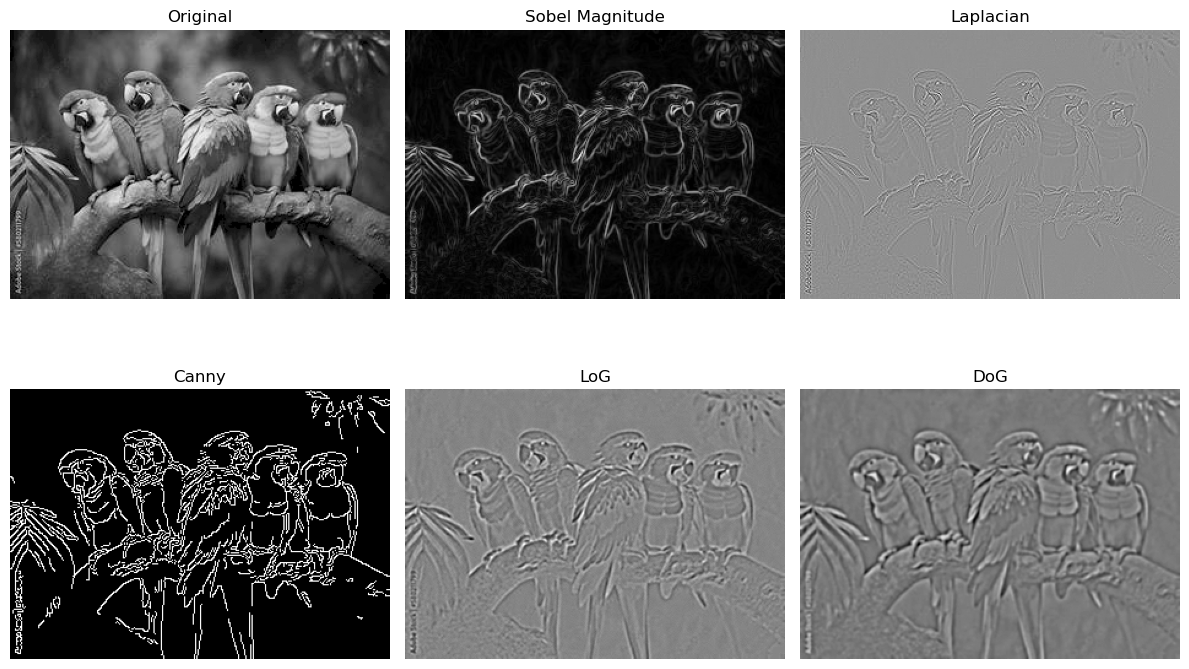

In [11]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(magnitude, cmap="gray")
plt.title("Sobel Magnitude")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(laplacian, cmap="gray")
plt.title("Laplacian")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(edges2, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(log, cmap="gray")
plt.title("LoG")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(dog1, cmap="gray")
plt.title("DoG")
plt.axis("off")

plt.tight_layout()
plt.show()

**Final Question:** If you had to pick one method to detect the edges of objects in **your** image, which would you choose and why? Mention at least two trade-offs (noise, detail, thickness of edges, speed...).

*Your answer:* 

I would choose Canny because the goal is to detect the actual boundaries of the birds and branch clearly, and its good noise resistance and thin edges make the result easier to interpret. The trade-off is that Canny is slower and may lose some fine details compared with simpler filters like Sobel

---

### Bonus (optional)
- Try your code on a second image with very different content (a face, text, a landscape) and describe what changed.
- Combine Sobel X and Y into the magnitude **without** using `np.sqrt` (hint: `cv2.magnitude`) and check that you get the same result.